In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [117]:
import warnings
warnings.filterwarnings('ignore')

In [118]:
df_tr = pd.read_csv("data/train.csv").drop(columns = "id")
df_ts = pd.read_csv("data/test.csv").drop(columns = "id")

df_tr

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,Premium,NaN,5.0,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0
1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,Comprehensive,NaN,10.0,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0
1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,Basic,0.0,19.0,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0
1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,Premium,1.0,7.0,407.0,4.0,2021-09-19 15:21:39.190215,Poor,No,Daily,Apartment,596.0


In [119]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1181295 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1155051 non-null  float64
 3   Marital Status        1181471 non-null  object 
 4   Number of Dependents  1090328 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Occupation            841925 non-null   object 
 7   Health Score          1125924 non-null  float64
 8   Location              1200000 non-null  object 
 9   Policy Type           1200000 non-null  object 
 10  Previous Claims       835971 non-null   float64
 11  Vehicle Age           1199994 non-null  float64
 12  Credit Score          1062118 non-null  float64
 13  Insurance Duration    1199999 non-null  float64
 14  Policy Start Date     1200000 non-

In [120]:
df_tr['Premium Amount'].rename("Premium_Amount")


0          2869.0
1          1483.0
2           567.0
3           765.0
4          2022.0
            ...  
1199995    1303.0
1199996     821.0
1199997     371.0
1199998     596.0
1199999    2480.0
Name: Premium_Amount, Length: 1200000, dtype: float64

In [121]:
df_tr.describe()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.181295e+06,1.155051e+06,1.090328e+06,1.125924e+06,835971.000000,1.199994e+06,1.062118e+06,1.199999e+06,1.200000e+06
mean,4.114556e+01,3.274522e+04,2.009934e+00,2.561391e+01,1.002689,9.569889e+00,5.929244e+02,5.018219e+00,1.102545e+03
std,1.353995e+01,3.217951e+04,1.417338e+00,1.220346e+01,0.982840,5.776189e+00,1.499819e+02,2.594331e+00,8.649989e+02
min,1.800000e+01,1.000000e+00,0.000000e+00,2.012237e+00,0.000000,0.000000e+00,3.000000e+02,1.000000e+00,2.000000e+01
25%,3.000000e+01,8.001000e+03,1.000000e+00,1.591896e+01,0.000000,5.000000e+00,4.680000e+02,3.000000e+00,5.140000e+02
50%,4.100000e+01,2.391100e+04,2.000000e+00,2.457865e+01,1.000000,1.000000e+01,5.950000e+02,5.000000e+00,8.720000e+02
75%,5.300000e+01,4.463400e+04,3.000000e+00,3.452721e+01,2.000000,1.500000e+01,7.210000e+02,7.000000e+00,1.509000e+03
max,6.400000e+01,1.499970e+05,4.000000e+00,5.897591e+01,9.000000,1.900000e+01,8.490000e+02,9.000000e+00,4.999000e+03


In [122]:

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression 
from  sklearn.metrics import  r2_score , mean_squared_error , mean_absolute_error   


In [123]:
dummies = pd.get_dummies(df_tr["Gender"], dtype=int)
df_tr = df_tr.drop(columns=["Gender"]).join(dummies)

dummies = pd.get_dummies(df_ts["Gender"], dtype=int)
df_ts = df_ts.drop(columns=["Gender"]).join(dummies)
df_tr

,Age,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,...,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Female,Male
0,19.0,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,...,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1,0
1,39.0,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,...,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1,0
2,23.0,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,...,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0,1
3,21.0,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,...,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0,1
4,21.0,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,...,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,Premium,NaN,...,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0,1,0
1199996,54.0,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,Comprehensive,NaN,...,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0,0,1
1199997,19.0,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,Basic,0.0,...,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0,0,1
1199998,55.0,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,Premium,1.0,...,407.0,4.0,2021-09-19 15:21:39.190215,Poor,No,Daily,Apartment,596.0,0,1


In [124]:
df_tr.columns

Index(['Age', 'Annual Income', 'Marital Status', 'Number of Dependents',
       'Education Level', 'Occupation', 'Health Score', 'Location',
       'Policy Type', 'Previous Claims', 'Vehicle Age', 'Credit Score',
       'Insurance Duration', 'Policy Start Date', 'Customer Feedback',
       'Smoking Status', 'Exercise Frequency', 'Property Type',
       'Premium Amount', 'Female', 'Male'],
      dtype='object')

In [125]:
from sklearn.preprocessing import StandardScaler

normalize_cols = [
    "Age",
    "Male",
    "Female",
    "Health Score",
    "Premium Amount"

]


scaler = StandardScaler()
df_tr[normalize_cols] = scaler.fit_transform(df_tr[normalize_cols])

In [142]:
df_tr.dropna(subset=['Age','Male','Female','Premium Amount'],axis=0,inplace=True)
df_tr['Age'] = df_tr['Age'].astype(int)
df_tr['Male'] = df_tr['Male'].astype(int)
df_tr['Female'] = df_tr['Female'].astype(int)
df_tr['Premium Amount'] = df_tr['Premium Amount'].astype(int)

X = df_tr[['Age','Male','Female']]
y = df_tr['Premium Amount']


In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [144]:
model = RandomForestRegressor(max_depth=3,n_estimators=300,max_features='log2')

In [145]:
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=3, max_features='log2', n_estimators=300)

Correlation with Premium Amount:

Premium Amount          1.000000
Previous Claims         0.046728
Health Score            0.014795
Vehicle Age             0.000468
Male                    0.000038
Female                 -0.000038
Insurance Duration     -0.000151
Number of Dependents   -0.000681
Age                    -0.002430
Annual Income          -0.012407
Credit Score           -0.026123
Name: Premium Amount, dtype: float64


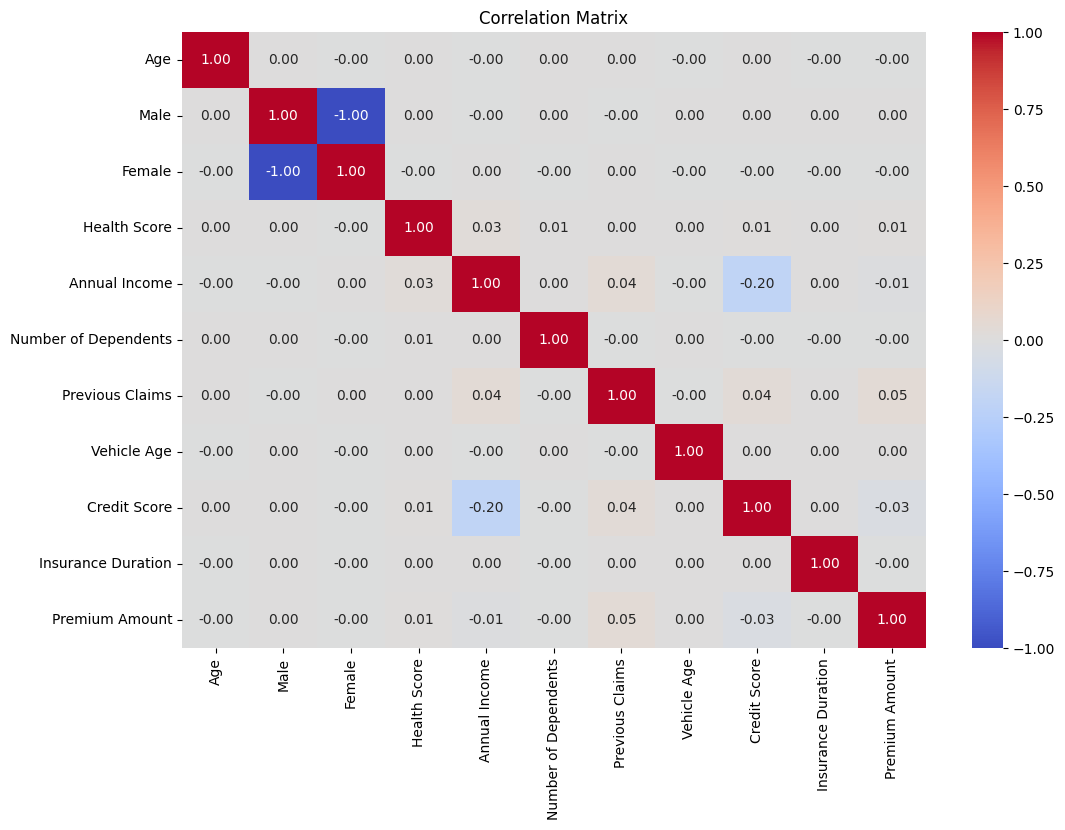

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_tr = pd.read_csv("data/train.csv").drop(columns="id")

dummies = pd.get_dummies(df_tr["Gender"], dtype=int)
df_tr = df_tr.drop(columns=["Gender"]).join(dummies)

df_tr.dropna(subset=['Age','Male','Female','Premium Amount'], inplace=True)

numeric_cols = ['Age','Male','Female','Health Score','Annual Income','Number of Dependents',
                'Previous Claims','Vehicle Age','Credit Score','Insurance Duration','Premium Amount']

df_numeric = df_tr[numeric_cols]

corr_matrix = df_numeric.corr()

print("Correlation with Premium Amount:\n")
print(corr_matrix['Premium Amount'].sort_values(ascending=False))

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

df_tr = pd.read_csv("data/train.csv").drop(columns="id")

dummies_gender = pd.get_dummies(df_tr["Gender"], dtype=int)
df_tr = df_tr.drop(columns=["Gender"]).join(dummies_gender)

df_tr['Policy Start Date'] = pd.to_datetime(df_tr['Policy Start Date'])
df_tr['Policy_Year'] = df_tr['Policy Start Date'].dt.year
df_tr['Policy_Month'] = df_tr['Policy Start Date'].dt.month
df_tr['Policy_Day'] = df_tr['Policy Start Date'].dt.day
df_tr = df_tr.drop(columns=['Policy Start Date'])

categorical_cols = [
    'Marital Status', 'Education Level', 'Occupation', 'Location',
    'Policy Type', 'Customer Feedback', 'Smoking Status',
    'Exercise Frequency', 'Property Type'
]

df_tr = pd.get_dummies(df_tr, columns=categorical_cols, drop_first=True)

numeric_cols = ['Age','Annual Income','Number of Dependents','Health Score',
                'Previous Claims','Vehicle Age','Credit Score','Insurance Duration','Premium Amount']

df_tr.dropna(subset=numeric_cols, inplace=True)

scaler = StandardScaler()
df_tr[numeric_cols] = scaler.fit_transform(df_tr[numeric_cols])

X = df_tr.drop(columns=['Premium Amount'])
y = df_tr['Premium Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',  
    n_jobs=-1
)

model.fit(X_train, y_train)

pred_tr = model.predict(X_train)
pred_ts = model.predict(X_test)

train_r2 = r2_score(y_train, pred_tr)
test_r2 = r2_score(y_test, pred_ts)
mse = mean_squared_error(y_test, pred_ts)
mae = mean_absolute_error(y_test, pred_ts)

print(f"Train R² Score: {train_r2*100:.2f}%")
print(f"Test R² Score: {test_r2*100:.2f}%")
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")


Train R² Score: 7.56%
Test R² Score: 3.92%
Test MSE: 0.96
Test MAE: 0.75
